In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

FIG_DIR = "/content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5"
TAB_DIR = "/content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5"

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)

print("Figure dir:", FIG_DIR)
print("Table dir:", TAB_DIR)

Figure dir: /content/drive/MyDrive/thesis_rl_trading_final/outputs/figures_ch5
Table dir: /content/drive/MyDrive/thesis_rl_trading_final/outputs/tables_ch5


In [3]:
# ============================================================
# CELL 02 — Imports
# ============================================================

import os
import json
import math
import warnings
from dataclasses import dataclass
from typing import Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [4]:
# ============================================================
# CELL 03 — Project config
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/thesis_rl_trading_final"

DATA_PROCESSED_DIR = f"{PROJECT_ROOT}/data_processed"
OUTPUTS_BENCHMARK_5Y_DIR = f"{PROJECT_ROOT}/outputs/benchmark_outputs_5y"
OUTPUTS_MODEL_DIR = f"{PROJECT_ROOT}/outputs/model_outputs"
CONFIGS_DIR = f"{PROJECT_ROOT}/configs"

for path in [
    DATA_PROCESSED_DIR,
    OUTPUTS_BENCHMARK_5Y_DIR,
    OUTPUTS_MODEL_DIR,
    CONFIGS_DIR,
]:
    os.makedirs(path, exist_ok=True)

with open(f"{CONFIGS_DIR}/master_config.json", "r") as f:
    master_cfg = json.load(f)

ASSETS = master_cfg["assets"]
TRANSACTION_COST = 0.001

print("ASSETS:", ASSETS)
print("OUTPUTS_BENCHMARK_5Y_DIR:", OUTPUTS_BENCHMARK_5Y_DIR)
print("OUTPUTS_MODEL_DIR:", OUTPUTS_MODEL_DIR)

ASSETS: ['AAPL', 'MSFT', 'AMZN', 'JPM', 'JNJ']
OUTPUTS_BENCHMARK_5Y_DIR: /content/drive/MyDrive/thesis_rl_trading_final/outputs/benchmark_outputs_5y
OUTPUTS_MODEL_DIR: /content/drive/MyDrive/thesis_rl_trading_final/outputs/model_outputs


In [5]:
# ============================================================
# CELL 04 — Load 5Y env-ready data
# ============================================================

env_ready_5y = np.load(f"{DATA_PROCESSED_DIR}/env_ready_5y.npz", allow_pickle=True)

data_5y = {
    "train": {
        "X": env_ready_5y["X_train"].astype(np.float32),
        "y": env_ready_5y["y_train"].astype(np.float32),
        "dates": env_ready_5y["dates_train"],
    },
    "val": {
        "X": env_ready_5y["X_val"].astype(np.float32),
        "y": env_ready_5y["y_val"].astype(np.float32),
        "dates": env_ready_5y["dates_val"],
    },
    "test": {
        "X": env_ready_5y["X_test"].astype(np.float32),
        "y": env_ready_5y["y_test"].astype(np.float32),
        "dates": env_ready_5y["dates_test"],
    },
}

for split in ["train", "val", "test"]:
    print(split, data_5y[split]["X"].shape, data_5y[split]["y"].shape, data_5y[split]["dates"].shape)

train (717, 20, 5, 13) (717, 5) (717,)
val (250, 20, 5, 13) (250, 5) (250,)
test (251, 20, 5, 13) (251, 5) (251,)


In [6]:
# ============================================================
# CELL 05 — PortfolioEnv
# ============================================================

@dataclass
class EnvStepResult:
    next_state: Optional[np.ndarray]
    reward: float
    done: bool
    info: Dict


class PortfolioEnv:
    def __init__(
        self,
        X: np.ndarray,
        y: np.ndarray,
        dates: np.ndarray,
        transaction_cost: float = 0.001,
        reward_mode: str = "cost_aware",
    ):
        assert reward_mode in ["cost_aware", "no_cost"]

        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.dates = dates
        self.transaction_cost = float(transaction_cost)
        self.reward_mode = reward_mode

        self.n_steps = self.X.shape[0]
        self.n_assets = self.X.shape[2]
        self.reset()

    def reset(self):
        self.t = 0
        self.prev_weights = np.ones(self.n_assets, dtype=np.float32) / self.n_assets
        self.portfolio_value = 1.0
        self.done = False
        return self.X[self.t]

    def _sanitize_action(self, action: np.ndarray) -> np.ndarray:
        action = np.asarray(action, dtype=np.float32).reshape(-1)
        action = np.clip(action, 1e-8, None)
        action = action / action.sum()
        return action.astype(np.float32)

    def step(self, action: np.ndarray) -> EnvStepResult:
        if self.done:
            raise RuntimeError("Episode already done. Call reset().")

        w_t = self._sanitize_action(action)
        r_t = self.y[self.t]

        portfolio_simple_return = float(np.dot(w_t, r_t))
        turnover = float(np.sum(np.abs(w_t - self.prev_weights)))
        trading_cost = self.transaction_cost * turnover

        portfolio_simple_return = max(portfolio_simple_return, -0.999999)

        reward_no_cost = math.log(1.0 + portfolio_simple_return)
        reward_cost_aware = reward_no_cost - trading_cost
        reward = reward_cost_aware if self.reward_mode == "cost_aware" else reward_no_cost

        gross_value_next = self.portfolio_value * (1.0 + portfolio_simple_return)
        net_value_next = gross_value_next * (1.0 - trading_cost)

        self.portfolio_value = float(net_value_next)
        self.prev_weights = w_t.copy()

        info = {
            "date": str(self.dates[self.t]),
            "weights": w_t.copy(),
            "portfolio_simple_return": portfolio_simple_return,
            "reward_no_cost": reward_no_cost,
            "reward_cost_aware": reward_cost_aware,
            "turnover": turnover,
            "trading_cost": trading_cost,
            "portfolio_value": self.portfolio_value,
        }

        self.t += 1
        self.done = (self.t >= self.n_steps)
        next_state = None if self.done else self.X[self.t]

        return EnvStepResult(next_state=next_state, reward=float(reward), done=self.done, info=info)

In [7]:
# ============================================================
# CELL 06 — Benchmark helpers
# ============================================================

def sample_random_weights(n_assets: int) -> np.ndarray:
    x = np.random.rand(n_assets).astype(np.float32)
    x = x / x.sum()
    return x


def run_policy_rollout(env: PortfolioEnv, policy_name: str = "random") -> pd.DataFrame:
    env.reset()
    rows = []

    while True:
        if policy_name == "equal_weight":
            action = np.ones(env.n_assets, dtype=np.float32) / env.n_assets
        elif policy_name == "random":
            action = sample_random_weights(env.n_assets)
        else:
            raise ValueError("Unsupported policy_name")

        result = env.step(action)

        rows.append({
            "date": result.info["date"],
            "portfolio_simple_return": result.info["portfolio_simple_return"],
            "turnover": result.info["turnover"],
            "trading_cost": result.info["trading_cost"],
            "portfolio_value": result.info["portfolio_value"],
        })

        if result.done:
            break

    return pd.DataFrame(rows)


def compute_metrics_from_rollout(df_rollout: pd.DataFrame) -> Dict:
    ret = df_rollout["portfolio_simple_return"].values
    pv = df_rollout["portfolio_value"].values
    turnover = df_rollout["turnover"].values

    cumulative_return = float(pv[-1] - 1.0)
    avg_daily_return = float(np.mean(ret))
    daily_volatility = float(np.std(ret))
    sharpe_approx = float(avg_daily_return / (daily_volatility + 1e-12) * np.sqrt(252))

    running_max = np.maximum.accumulate(pv)
    drawdown = pv / (running_max + 1e-12) - 1.0
    max_drawdown = float(np.min(drawdown))

    avg_turnover = float(np.mean(turnover))
    total_trading_cost = float(df_rollout["trading_cost"].sum())
    avg_trading_cost = float(df_rollout["trading_cost"].mean())

    return {
        "n_steps": int(len(df_rollout)),
        "final_portfolio_value": float(pv[-1]),
        "cumulative_return": cumulative_return,
        "avg_daily_return": avg_daily_return,
        "daily_volatility": daily_volatility,
        "sharpe_approx": sharpe_approx,
        "max_drawdown": max_drawdown,
        "avg_turnover": avg_turnover,
        "total_trading_cost": total_trading_cost,
        "avg_trading_cost": avg_trading_cost,
    }

In [8]:
# ============================================================
# CELL 07 — Run equal-weight and random benchmarks on 5Y
# ============================================================

benchmark_rollouts_5y = {
    "Equal_Weight": {},
    "Random_Policy": {},
}

for split in ["train", "val", "test"]:
    env_eq = PortfolioEnv(
        X=data_5y[split]["X"],
        y=data_5y[split]["y"],
        dates=data_5y[split]["dates"],
        transaction_cost=TRANSACTION_COST,
        reward_mode="cost_aware",
    )
    env_rand = PortfolioEnv(
        X=data_5y[split]["X"],
        y=data_5y[split]["y"],
        dates=data_5y[split]["dates"],
        transaction_cost=TRANSACTION_COST,
        reward_mode="cost_aware",
    )

    benchmark_rollouts_5y["Equal_Weight"][split] = run_policy_rollout(env_eq, policy_name="equal_weight")
    benchmark_rollouts_5y["Random_Policy"][split] = run_policy_rollout(env_rand, policy_name="random")

    print(split,
          benchmark_rollouts_5y["Equal_Weight"][split].shape,
          benchmark_rollouts_5y["Random_Policy"][split].shape)

train (717, 5) (717, 5)
val (250, 5) (250, 5)
test (251, 5) (251, 5)


In [9]:
# ============================================================
# CELL 08 — Compute equal-weight and random metrics
# ============================================================

benchmark_rows_core_5y = []

for model_name in ["Equal_Weight", "Random_Policy"]:
    for split in ["train", "val", "test"]:
        metrics = compute_metrics_from_rollout(benchmark_rollouts_5y[model_name][split])
        benchmark_rows_core_5y.append({
            "model": model_name,
            "split": split,
            **metrics,
        })

benchmark_core_metrics_5y = pd.DataFrame(benchmark_rows_core_5y)
display(benchmark_core_metrics_5y)

,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,Equal_Weight,train,717,1.399084,0.399084,0.000615,0.017128,0.570165,-0.259889,0.000000,0.000000,0.000000
1,Equal_Weight,val,250,1.379212,0.379212,0.001332,0.009508,2.223801,-0.102027,0.000000,0.000000,0.000000
2,Equal_Weight,test,251,1.250141,0.250141,0.000926,0.008450,1.738956,-0.088813,0.000000,0.000000,0.000000
3,Random_Policy,train,717,0.947786,-0.052214,0.000731,0.017417,0.666131,-0.362489,0.653538,0.468587,0.000654
4,Random_Policy,val,250,1.219261,0.219261,0.001467,0.009891,2.354425,-0.125223,0.623923,0.155981,0.000624
5,Random_Policy,test,251,1.000808,0.000808,0.000679,0.009373,1.149663,-0.104923,0.631121,0.158411,0.000631


In [10]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=benchmark_core_metrics_5y)

https://docs.google.com/spreadsheets/d/1HCrwKvSPc-0DaBP6lYSJpWbFxcJOOIFXvTubERq7YHw/edit#gid=0


In [11]:
# ============================================================
# CELL 08B — Save equal-weight and random rollout files
# ============================================================

for split in ["train", "val", "test"]:
    benchmark_rollouts_5y["Equal_Weight"][split].to_csv(
        f"{OUTPUTS_BENCHMARK_5Y_DIR}/equal_weight_rollout_{split}_5y.csv",
        index=False
    )
    benchmark_rollouts_5y["Random_Policy"][split].to_csv(
        f"{OUTPUTS_BENCHMARK_5Y_DIR}/random_policy_rollout_{split}_5y.csv",
        index=False
    )

print("Saved equal-weight and random-policy rollout files for 5Y.")

Saved equal-weight and random-policy rollout files for 5Y.


In [12]:
# ============================================================
# CELL 09 — Load buy-and-hold metrics and rollout files
# ============================================================

buyhold_metrics_5y = pd.read_csv(f"{OUTPUTS_BENCHMARK_5Y_DIR}/buyhold_equalweight_metrics_5y.csv")

buyhold_rollouts_5y = {
    "train": pd.read_csv(f"{OUTPUTS_BENCHMARK_5Y_DIR}/buyhold_equalweight_rollout_train_5y.csv"),
    "val": pd.read_csv(f"{OUTPUTS_BENCHMARK_5Y_DIR}/buyhold_equalweight_rollout_val_5y.csv"),
    "test": pd.read_csv(f"{OUTPUTS_BENCHMARK_5Y_DIR}/buyhold_equalweight_rollout_test_5y.csv"),
}

print("buyhold_metrics_5y:", buyhold_metrics_5y.shape)
display(buyhold_metrics_5y)

buyhold_metrics_5y: (3, 12)


,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,BuyHold_EqualWeight,train,717,1.341765,0.341765,0.000565,0.017593,0.509788,-0.281512,0.0,0.0,0.0
1,BuyHold_EqualWeight,val,250,1.390120,0.390120,0.001370,0.010120,2.148305,-0.102857,0.0,0.0,0.0
2,BuyHold_EqualWeight,test,251,1.249163,0.249163,0.000925,0.008739,1.680247,-0.096735,0.0,0.0,0.0


In [13]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=buyhold_metrics_5y)

https://docs.google.com/spreadsheets/d/1uFz5-QDLkvHAaihpr5y9MBqKaWKs0E4nulJ4u5FGPdQ/edit#gid=0


In [14]:
# ============================================================
# CELL 10 — Load trained model summaries
# ============================================================

def ensure_summary_has_cost_columns(summary_df: pd.DataFrame, model_dir: str) -> pd.DataFrame:
    summary_df = summary_df.copy()

    needed_cols = ["total_trading_cost", "avg_trading_cost"]
    if all(col in summary_df.columns for col in needed_cols):
        return summary_df

    cost_rows = []
    for split in ["train", "val", "test"]:
        rollout_path = f"{model_dir}/{split}_rollout_best.csv"
        rollout_df = pd.read_csv(rollout_path)

        total_trading_cost = float(rollout_df["trading_cost"].sum())
        avg_trading_cost = float(rollout_df["trading_cost"].mean())

        cost_rows.append({
            "split": split,
            "total_trading_cost": total_trading_cost,
            "avg_trading_cost": avg_trading_cost,
        })

    cost_df = pd.DataFrame(cost_rows)
    summary_df = summary_df.merge(cost_df, on="split", how="left")

    return summary_df


mlp_summary_5y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/mlp_ppo_5y/summary_metrics_best.csv")
lstm_summary_5y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/lstm_ppo_5y/summary_metrics_best.csv")
transformer_summary_5y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/transformer_ppo_final_5y/summary_metrics_best.csv")

mlp_summary_5y = ensure_summary_has_cost_columns(
    mlp_summary_5y,
    f"{OUTPUTS_MODEL_DIR}/mlp_ppo_5y"
)
lstm_summary_5y = ensure_summary_has_cost_columns(
    lstm_summary_5y,
    f"{OUTPUTS_MODEL_DIR}/lstm_ppo_5y"
)
transformer_summary_5y = ensure_summary_has_cost_columns(
    transformer_summary_5y,
    f"{OUTPUTS_MODEL_DIR}/transformer_ppo_final_5y"
)

mlp_summary_5y["model"] = "MLP_PPO"
lstm_summary_5y["model"] = "LSTM_PPO"
transformer_summary_5y["model"] = "Transformer_PPO"

print("mlp_summary_5y:", mlp_summary_5y.shape)
print("lstm_summary_5y:", lstm_summary_5y.shape)
print("transformer_summary_5y:", transformer_summary_5y.shape)

mlp_summary_5y: (3, 12)
lstm_summary_5y: (3, 12)
transformer_summary_5y: (3, 12)


In [15]:
# ============================================================
# CELL 11 — Build full 5Y benchmark table
# ============================================================

benchmark_metrics_5y = pd.concat([
    benchmark_core_metrics_5y,
    buyhold_metrics_5y[[
        "model", "split", "n_steps", "final_portfolio_value", "cumulative_return",
        "avg_daily_return", "daily_volatility", "sharpe_approx", "max_drawdown",
        "avg_turnover", "total_trading_cost", "avg_trading_cost"
    ]],
    mlp_summary_5y[[
        "model", "split", "n_steps", "final_portfolio_value", "cumulative_return",
        "avg_daily_return", "daily_volatility", "sharpe_approx", "max_drawdown",
        "avg_turnover", "total_trading_cost", "avg_trading_cost"
    ]],
    lstm_summary_5y[[
        "model", "split", "n_steps", "final_portfolio_value", "cumulative_return",
        "avg_daily_return", "daily_volatility", "sharpe_approx", "max_drawdown",
        "avg_turnover", "total_trading_cost", "avg_trading_cost"
    ]],
    transformer_summary_5y[[
        "model", "split", "n_steps", "final_portfolio_value", "cumulative_return",
        "avg_daily_return", "daily_volatility", "sharpe_approx", "max_drawdown",
        "avg_turnover", "total_trading_cost", "avg_trading_cost"
    ]],
], axis=0, ignore_index=True)

model_order = [
    "Equal_Weight",
    "BuyHold_EqualWeight",
    "Random_Policy",
    "MLP_PPO",
    "LSTM_PPO",
    "Transformer_PPO",
]
split_order = ["train", "val", "test"]

benchmark_metrics_5y["model"] = pd.Categorical(benchmark_metrics_5y["model"], categories=model_order, ordered=True)
benchmark_metrics_5y["split"] = pd.Categorical(benchmark_metrics_5y["split"], categories=split_order, ordered=True)

benchmark_metrics_5y = benchmark_metrics_5y.sort_values(["split", "model"]).reset_index(drop=True)
benchmark_metrics_5y.to_csv(f"{TAB_DIR}/benchmarks_5y.csv", index=False)
display(benchmark_metrics_5y)

,model,split,n_steps,final_portfolio_value,cumulative_return,avg_daily_return,daily_volatility,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,avg_trading_cost
0,Equal_Weight,train,717,1.399084,0.399084,0.000615,0.017128,0.570165,-0.259889,0.000000,0.000000,0.000000
1,BuyHold_EqualWeight,train,717,1.341765,0.341765,0.000565,0.017593,0.509788,-0.281512,0.000000,0.000000,0.000000
2,Random_Policy,train,717,0.947786,-0.052214,0.000731,0.017417,0.666131,-0.362489,0.653538,0.468587,0.000654
3,MLP_PPO,train,717,1.315822,0.315822,0.000934,0.018129,0.817849,-0.319734,0.386254,0.276944,0.000386
4,LSTM_PPO,train,717,1.244301,0.244301,0.000673,0.017731,0.602927,-0.319758,0.210692,0.151066,0.000211
5,Transformer_PPO,train,717,1.366996,0.366996,0.000896,0.017306,0.822063,-0.277366,0.310084,0.222330,0.000310
6,Equal_Weight,val,250,1.379212,0.379212,0.001332,0.009508,2.223801,-0.102027,0.000000,0.000000,0.000000
7,BuyHold_EqualWeight,val,250,1.390120,0.390120,0.001370,0.010120,2.148305,-0.102857,0.000000,0.000000,0.000000
8,Random_Policy,val,250,1.219261,0.219261,0.001467,0.009891,2.354425,-0.125223,0.623923,0.155981,0.000624
9,MLP_PPO,val,250,1.381177,0.381177,0.001614,0.009645,2.657055,-0.105376,0.274928,0.068732,0.000275


In [16]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=benchmark_metrics_5y)

https://docs.google.com/spreadsheets/d/1N3nMraDc9ZUhujghQFfvZrrtBfvPAWNgwbv6khi6PH4/edit#gid=0


In [18]:
# ============================================================
# CELL 12 — Build 5Y test leaderboard
# ============================================================

leaderboard_test_5y = (
    benchmark_metrics_5y[benchmark_metrics_5y["split"] == "test"][
        ["model", "cumulative_return", "sharpe_approx", "max_drawdown", "avg_turnover", "total_trading_cost"]
    ]
    .sort_values("cumulative_return", ascending=False)
    .reset_index(drop=True)
)

leaderboard_test_5y["rank_test_cumret"] = np.arange(1, len(leaderboard_test_5y) + 1)
leaderboard_test_5y.to_csv(f"{TAB_DIR}/benchmarks_5y_test_leaderboard.csv", index=False)
display(leaderboard_test_5y)

,model,cumulative_return,sharpe_approx,max_drawdown,avg_turnover,total_trading_cost,rank_test_cumret
0,Equal_Weight,0.250141,1.738956,-0.088813,0.000000,0.000000,1
1,BuyHold_EqualWeight,0.249163,1.680247,-0.096735,0.000000,0.000000,2
2,Transformer_PPO,0.194722,1.574676,-0.105164,0.216549,0.054354,3
3,LSTM_PPO,0.169186,1.537707,-0.091065,0.191343,0.048027,4
4,MLP_PPO,0.121174,1.420692,-0.096780,0.267925,0.067249,5
5,Random_Policy,0.000808,1.149663,-0.104923,0.631121,0.158411,6


In [19]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=leaderboard_test_5y)

https://docs.google.com/spreadsheets/d/1lvWpeb9awScf2mFPI0OS6erjOqaDoRRFq16m7aBaucM/edit#gid=0


In [20]:
# ============================================================
# CELL 13 — Save final 5Y benchmark tables
# ============================================================

benchmark_metrics_5y.to_csv(f"{OUTPUTS_BENCHMARK_5Y_DIR}/benchmark_metrics_5y.csv", index=False)
leaderboard_test_5y.to_csv(f"{OUTPUTS_BENCHMARK_5Y_DIR}/leaderboard_test_5y.csv", index=False)

print("Saved:")
print(f"{OUTPUTS_BENCHMARK_5Y_DIR}/benchmark_metrics_5y.csv")
print(f"{OUTPUTS_BENCHMARK_5Y_DIR}/leaderboard_test_5y.csv")

Saved:
/content/drive/MyDrive/thesis_rl_trading_final/outputs/benchmark_outputs_5y/benchmark_metrics_5y.csv
/content/drive/MyDrive/thesis_rl_trading_final/outputs/benchmark_outputs_5y/leaderboard_test_5y.csv


In [21]:
# ============================================================
# CELL 14 — Load test rollout files for plot
# ============================================================

mlp_test_rollout_5y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/mlp_ppo_5y/test_rollout_best.csv")
lstm_test_rollout_5y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/lstm_ppo_5y/test_rollout_best.csv")
transformer_test_rollout_5y = pd.read_csv(f"{OUTPUTS_MODEL_DIR}/transformer_ppo_final_5y/test_rollout_best.csv")

eq_test_rollout_5y = benchmark_rollouts_5y["Equal_Weight"]["test"]
rand_test_rollout_5y = benchmark_rollouts_5y["Random_Policy"]["test"]
buyhold_test_rollout_5y = buyhold_rollouts_5y["test"]

print("Loaded all 5Y test rollouts.")

Loaded all 5Y test rollouts.


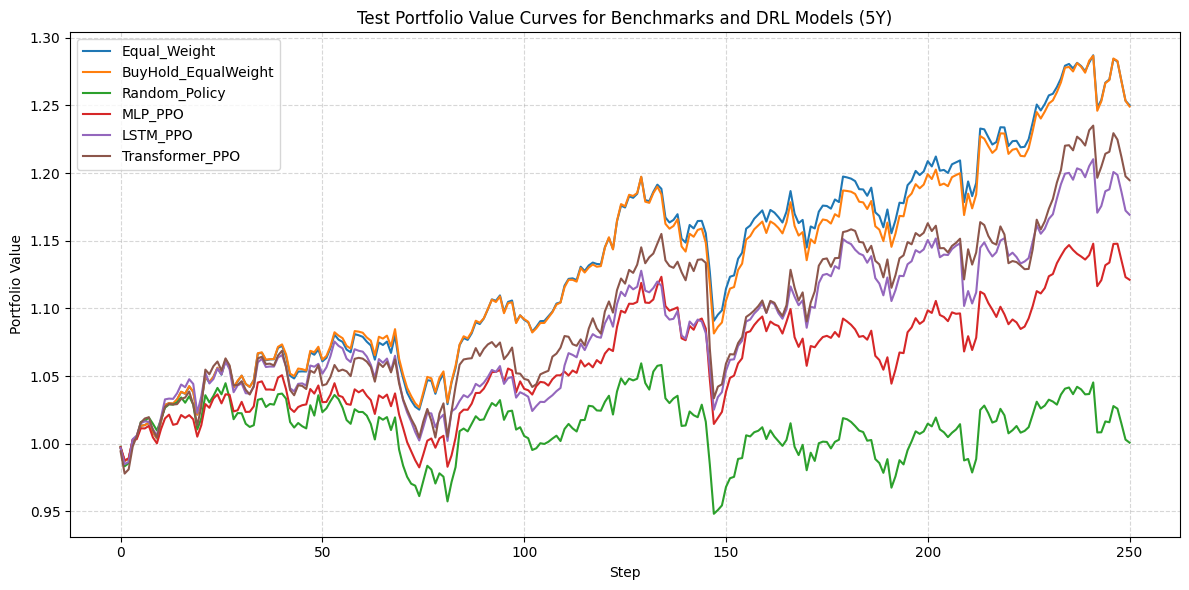

In [22]:
# ============================================================
# CELL 15 — Plot 5Y test portfolio value curves
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(eq_test_rollout_5y["portfolio_value"].values, label="Equal_Weight")
plt.plot(buyhold_test_rollout_5y["portfolio_value"].values, label="BuyHold_EqualWeight")
plt.plot(rand_test_rollout_5y["portfolio_value"].values, label="Random_Policy")
plt.plot(mlp_test_rollout_5y["portfolio_value"].values, label="MLP_PPO")
plt.plot(lstm_test_rollout_5y["portfolio_value"].values, label="LSTM_PPO")
plt.plot(transformer_test_rollout_5y["portfolio_value"].values, label="Transformer_PPO")

plt.title("Test Portfolio Value Curves for Benchmarks and DRL Models (5Y)")
plt.xlabel("Step")
plt.ylabel("Portfolio Value")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/benchmark_curves_5y_backup.png", dpi=300, bbox_inches="tight")
plt.show()

In [24]:
# ============================================================
# CELL 16 — Build benchmark interpretation summary
# ============================================================

top_5y = leaderboard_test_5y.iloc[0]
top_learned_5y = leaderboard_test_5y[leaderboard_test_5y["model"].isin(["MLP_PPO", "LSTM_PPO", "Transformer_PPO"])].iloc[0]

benchmark_interpretation_5y = pd.DataFrame([
    {
        "topic": "Benchmark 5Y Overall",
        "finding": f"Best overall 5Y test result was {top_5y['model']}",
        "evidence": f"Test cumulative return = {top_5y['cumulative_return']:.6f}",
    },
    {
        "topic": "Benchmark 5Y Learned Models",
        "finding": f"Best learned 5Y test result was {top_learned_5y['model']}",
        "evidence": f"Test cumulative return = {top_learned_5y['cumulative_return']:.6f}",
    },
    {
        "topic": "Benchmark 5Y Passive Baselines",
        "finding": "Equal-weight and buy-and-hold were both highly competitive passive benchmarks",
        "evidence": "Observed in the test leaderboard and portfolio value curves",
    },
])
benchmark_interpretation_5y.to_csv(f"{TAB_DIR}/benchmark_summary_5y.csv", index=False)

display(benchmark_interpretation_5y)

,topic,finding,evidence
0,Benchmark 5Y Overall,Best overall 5Y test result was Equal_Weight,Test cumulative return = 0.250141
1,Benchmark 5Y Learned Models,Best learned 5Y test result was Transformer_PPO,Test cumulative return = 0.194722
2,Benchmark 5Y Passive Baselines,Equal-weight and buy-and-hold were both highly...,Observed in the test leaderboard and portfolio...


In [25]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=benchmark_interpretation_5y)

https://docs.google.com/spreadsheets/d/1SL4TQXvDjd7SjccCV7Yif-4xAtZQg5tlIiD4h301fgY/edit#gid=0


In [26]:
# ============================================================
# CELL 17 — Save interpretation summary
# ============================================================

benchmark_interpretation_5y.to_csv(
    f"{OUTPUTS_BENCHMARK_5Y_DIR}/benchmark_interpretation_5y.csv",
    index=False
)

print("Saved:", f"{OUTPUTS_BENCHMARK_5Y_DIR}/benchmark_interpretation_5y.csv")

Saved: /content/drive/MyDrive/thesis_rl_trading_final/outputs/benchmark_outputs_5y/benchmark_interpretation_5y.csv


In [27]:
# ============================================================
# CELL 18 — Final sanity checks
# ============================================================

required_files = [
    f"{OUTPUTS_BENCHMARK_5Y_DIR}/benchmark_metrics_5y.csv",
    f"{OUTPUTS_BENCHMARK_5Y_DIR}/leaderboard_test_5y.csv",
    f"{OUTPUTS_BENCHMARK_5Y_DIR}/benchmark_interpretation_5y.csv",
]

for fp in required_files:
    assert os.path.exists(fp), f"Missing file: {fp}"

print("All updated 5Y benchmark notebook checks passed.")

All updated 5Y benchmark notebook checks passed.
